# Phase 1: Exploratory Data Analysis (EDA)
## Customer Churn & LTV Prediction Engine

This notebook guides you through the initial ingestion, validation, and exploratory profiling of the **IBM Telco Customer Churn** dataset. EDA is a critical foundation for detecting anomalies, understanding correlations, and identifying high-value features for predictive modeling.

### Objectives:
1. Ingest dataset using modular loading scripts.
2. Profile data distributions, missing values, and type castings.
3. Investigate the target variable (`Churn`) distribution.
4. Analyze numerical and categorical inputs relative to churn risk.
5. Prepare insights for the subsequent data cleaning and engineering phases.

### Step 1: Environment Setup and Library Imports

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load raw dataset directly (no src module needed) ─────────────────────────
RAW_PATH = os.path.join(os.path.abspath(".."), "data", "raw",
                        "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw = pd.read_csv(RAW_PATH)

# ── Quick schema check ───────────────────────────────────────────────────────
REQUIRED_COLS = [
    "customerID","gender","SeniorCitizen","Partner","Dependents","tenure",
    "PhoneService","MultipleLines","InternetService","OnlineSecurity",
    "OnlineBackup","DeviceProtection","TechSupport","StreamingTV",
    "StreamingMovies","Contract","PaperlessBilling","PaymentMethod",
    "MonthlyCharges","TotalCharges","Churn"
]
missing = set(REQUIRED_COLS) - set(df_raw.columns)
assert not missing, f"Missing columns: {missing}"
print(f"Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print("All required columns present ✓")

# ── Visualisation defaults ────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


Dataset loaded: 7,043 rows x 21 columns
All required columns present ✓


### Step 2: Ingest the Raw Dataset

> **Manual Action Required:** Before executing this block, make sure you have downloaded the IBM Telco Churn CSV and placed it at `data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv` (see instructions in README).

In [2]:
# Verify dataset loaded correctly and check schema
try:
    print(f"Dataset shape    : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
    print(f"Missing values   : {df_raw.isnull().sum().sum()}")

    # Inline schema check (no src module needed)
    REQUIRED_COLS = [
        "customerID","gender","SeniorCitizen","Partner","Dependents","tenure",
        "PhoneService","MultipleLines","InternetService","OnlineSecurity",
        "OnlineBackup","DeviceProtection","TechSupport","StreamingTV",
        "StreamingMovies","Contract","PaperlessBilling","PaymentMethod",
        "MonthlyCharges","TotalCharges","Churn"
    ]
    missing_cols = set(REQUIRED_COLS) - set(df_raw.columns)
    if missing_cols:
        print(f"[Warning] Missing columns: {missing_cols}")
    else:
        print("Schema validation passed: all required columns present")

    print()
    print(df_raw.dtypes)
except Exception as e:
    print(f"[Error] {e}")


Dataset shape    : 7,043 rows x 21 columns
Missing values   : 0
Schema validation passed: all required columns present

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


### Step 3: Initial Data Profiling and Cleansing Check

In [3]:
# Inspect first few rows
if 'df_raw' in locals():
    display(df_raw.head())
else:
    print("Dataset is not loaded yet.")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# View shape, column names, null counts, and data types
if 'df_raw' in locals():
    print("--- Data Types and Non-Null Summary ---")
    df_raw.info()
    
    print("\n--- Missing Values Profile ---")
    missing = df_raw.isnull().sum()
    print(missing[missing > 0])
    
    print("\n--- Blank spaces in object columns ---")
    # TotalCharges is read as object, inspect why (whitespace check)
    space_count = (df_raw['TotalCharges'] == ' ').sum() if 'TotalCharges' in df_raw.columns else 0
    print(f"Blank spaces (' ') found in 'TotalCharges': {space_count}")

--- Data Types and Non-Null Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBill

### Step 4: Target Variable Profiling (`Churn`)

Understanding target class distribution is vital to identify if class imbalance is a concern.

Churn count: Yes = 1869, No = 5174
Churn rate: Yes = 26.54%, No = 73.46%


C:\Users\Rudra Pratap Giri\AppData\Local\Temp\ipykernel_22180\2473782875.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_raw, palette='Set2')


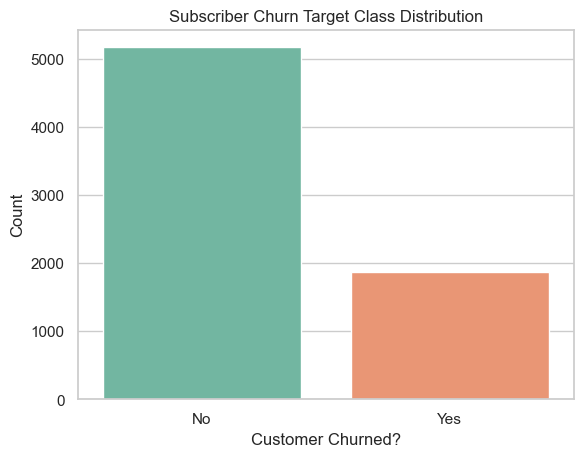

In [5]:
if 'df_raw' in locals():
    churn_counts = df_raw['Churn'].value_counts()
    churn_pct = df_raw['Churn'].value_counts(normalize=True) * 100
    
    print(f"Churn count: Yes = {churn_counts.get('Yes', 0)}, No = {churn_counts.get('No', 0)}")
    print(f"Churn rate: Yes = {churn_pct.get('Yes', 0.0):.2f}%, No = {churn_pct.get('No', 0.0):.2f}%")
    
    # Visualise the target distribution
    sns.countplot(x='Churn', data=df_raw, palette='Set2')
    plt.title("Subscriber Churn Target Class Distribution")
    plt.xlabel("Customer Churned?")
    plt.ylabel("Count")
    plt.show()

### Step 5: Numerical Feature Distributions

Let's inspect the spread of key numerical variables: `tenure`, `MonthlyCharges`, and `TotalCharges` (cast to float first).

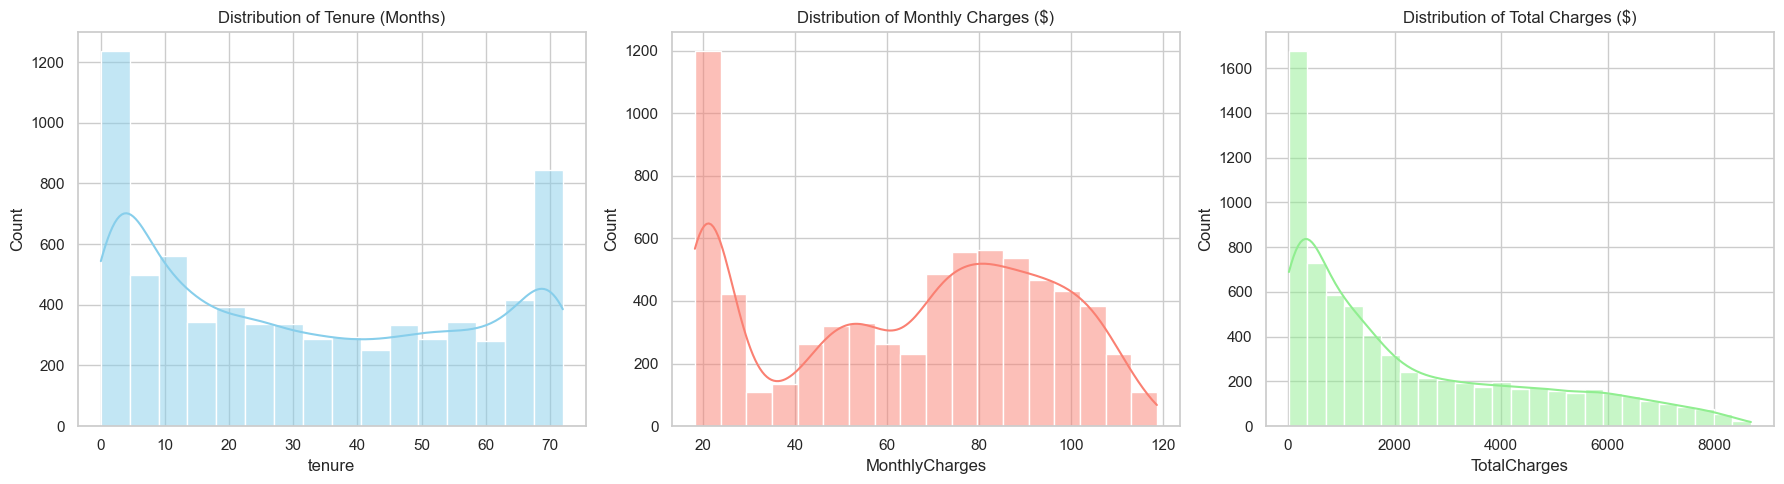

In [6]:
if 'df_raw' in locals():
    df_temp = df_raw.copy()
    # Convert TotalCharges for distribution plotting
    df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'].replace(' ', np.nan), errors='coerce')
    
    # Plot numerical histograms
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.histplot(df_temp['tenure'], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title("Distribution of Tenure (Months)")
    
    sns.histplot(df_temp['MonthlyCharges'], kde=True, ax=axes[1], color='salmon')
    axes[1].set_title("Distribution of Monthly Charges ($)")
    
    sns.histplot(df_temp['TotalCharges'], kde=True, ax=axes[2], color='lightgreen')
    axes[2].set_title("Distribution of Total Charges ($)")
    
    plt.tight_layout()
    plt.show()

### Step 6: Bivariate Analysis (Numerical Features vs. Churn)

Examine if tenure and subscription cost rates differ significantly between churned and active subscribers.

C:\Users\Rudra Pratap Giri\AppData\Local\Temp\ipykernel_22180\1949378144.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_raw, ax=axes[0], palette='Set2')
C:\Users\Rudra Pratap Giri\AppData\Local\Temp\ipykernel_22180\1949378144.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df_raw, ax=axes[1], palette='Set2')


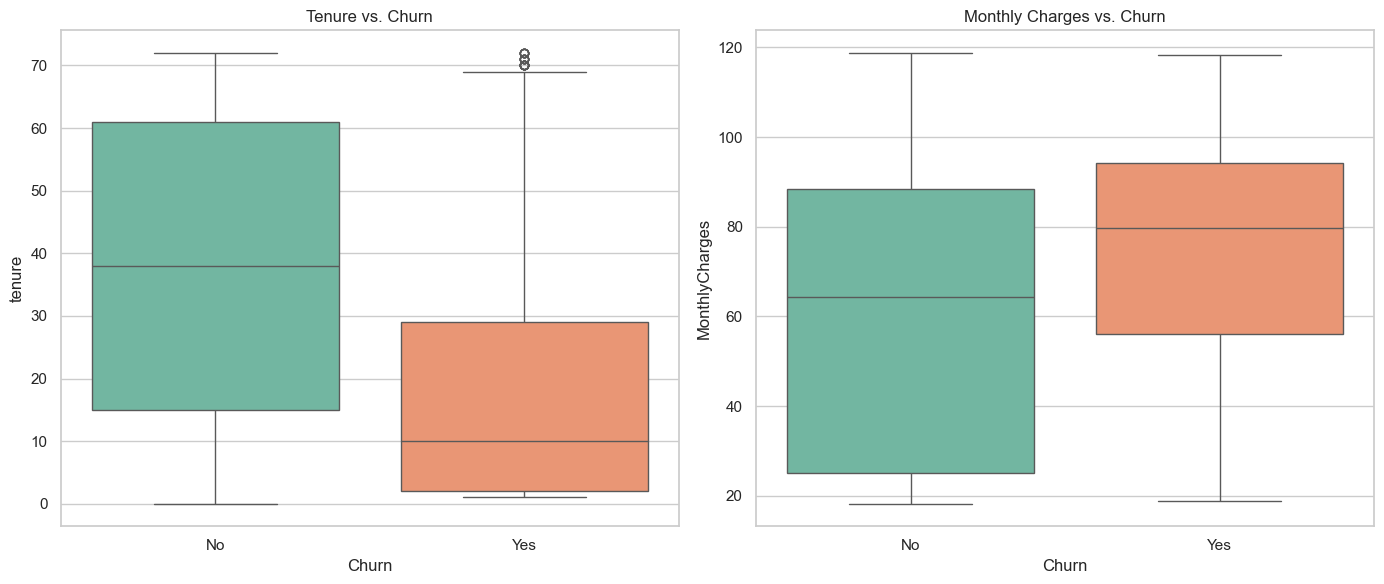

In [7]:
if 'df_raw' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    sns.boxplot(x='Churn', y='tenure', data=df_raw, ax=axes[0], palette='Set2')
    axes[0].set_title("Tenure vs. Churn")
    
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df_raw, ax=axes[1], palette='Set2')
    axes[1].set_title("Monthly Charges vs. Churn")
    
    plt.tight_layout()
    plt.show()

### Step 7: Categorical Variables and Service Subscriptions

Assess relationship between products subscribed to (Internet service, online safety, contracts) and Churn rate.

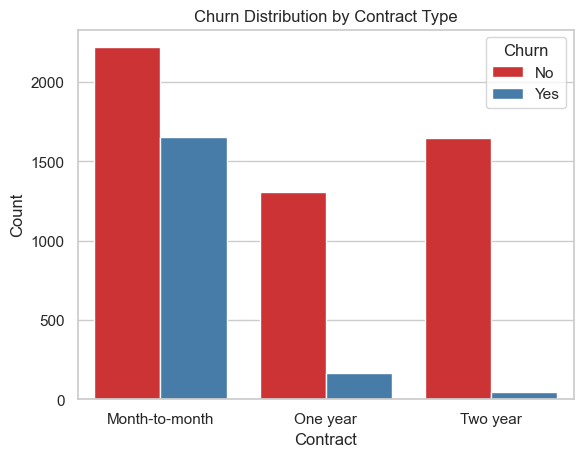

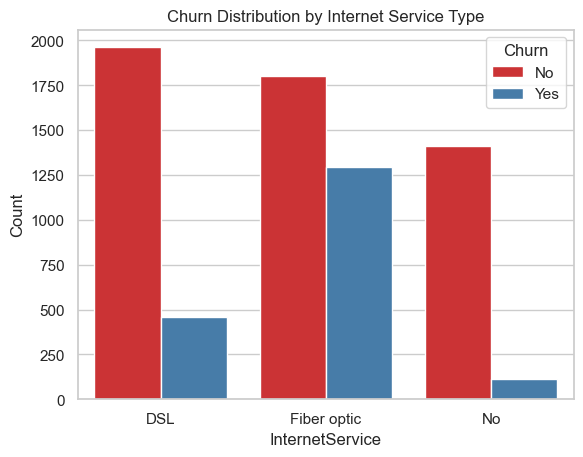

In [8]:
if 'df_raw' in locals():
    # Review Contract Types
    sns.countplot(x='Contract', hue='Churn', data=df_raw, palette='Set1')
    plt.title("Churn Distribution by Contract Type")
    plt.ylabel("Count")
    plt.show()
    
    # Review Internet Service Types
    sns.countplot(x='InternetService', hue='Churn', data=df_raw, palette='Set1')
    plt.title("Churn Distribution by Internet Service Type")
    plt.ylabel("Count")
    plt.show()

### Summary of Initial Key Findings (Editable)

Based on the analysis, compile your notes below:
- **Class Imbalance:** Roughly 26.5% churn, meaning some metric stratification is needed during training.
- **Tenure Effect:** Customers who churn tend to do so early in their lifecycle (low tenure boxplot median).
- **Charges Effect:** High monthly charges correlate with higher churn ratios.
- **Contracts:** Month-to-month contracts represent the highest density of churning accounts.